# 2026 Regime Adaptation Strategy — Hybrid Hawk/Dove Intraday Backtest

Combines the best signals from prior analysis:
- **Hawk trades**: Level signal (`trailing_5_avg >= 10`) + relevance gate (`relevance_scored_pct >= 40`)
- **Dove trades**: Personal surprise signal (`hawk_dove_score - trailing_5_avg <= -10`) + relevance gate
- **Comparison**: Trailing Shift standalone (`delta_trailing_5 >= ±5`) and baseline (level only, no filters)

Rationale: Level signal works for hawks (Sharpe 1.01) but dove trades are net-negative across all level metrics.
Personal surprise is the only metric that makes dove trades profitable (+28.6 bps). Relevance gate
eliminates junk trades on non-policy speeches (supervision, AI, payments) where labels are stale.

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, r"C:\Users\chris\clee\ARBS")
import datetime, pytz, re, numpy as np, pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt, matplotlib.pylab as pylab, seaborn as sns
plt.style.use("ggplot")
pylab.rcParams.update({"legend.fontsize": "large", "figure.figsize": (14, 8),
    "axes.labelsize": "x-large", "axes.titlesize": "x-large",
    "xtick.labelsize": "large", "ytick.labelsize": "large"})
import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")
ENTRY_OFFSET = datetime.timedelta(minutes=45)
EXIT_OFFSET  = datetime.timedelta(minutes=180)
CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"
BASE_BPV = 100_000
MDP_SOURCE = "BARCHART_STIRF-RL"
BT_START = "2021-01-01"
BT_END   = "2026-06-24"

# Signal thresholds
HAWK_LEVEL_THRESH   = 10
DOVE_SURPRISE_THRESH = -10
SHIFT_THRESH        = 5
RELEVANCE_GATE      = 40

EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH   = datetime.time(17, 0)
BLACKOUT_BD = 1

print("Config loaded.")

Config loaded.


## 1. Load Data

In [2]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme
fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS], show_tqdm=True, bulk_chunk_weeks=52)
print(f"ForexFactory events: {len(fed_speak_df)}")

jpm = pd.read_csv(r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv")
jpm["date"] = pd.to_datetime(jpm["date"]).dt.date
jpm = jpm.sort_values(["speaker", "date"]).reset_index(drop=True)
KNOWN_SPEAKERS = sorted(jpm["speaker"].unique())
print(f"JPM speakers: {len(KNOWN_SPEAKERS)}")

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

ForexFactory events: 1477
JPM speakers: 23


## 2. Backtest Engine & Signal Definitions

In [3]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

FOMC_DATES = [
    datetime.date(2020,1,29),datetime.date(2020,3,15),datetime.date(2020,4,29),
    datetime.date(2020,6,10),datetime.date(2020,7,29),datetime.date(2020,9,16),
    datetime.date(2020,11,5),datetime.date(2020,12,16),
    datetime.date(2021,1,27),datetime.date(2021,3,17),datetime.date(2021,4,28),
    datetime.date(2021,6,16),datetime.date(2021,7,28),datetime.date(2021,9,22),
    datetime.date(2021,11,3),datetime.date(2021,12,15),
    datetime.date(2022,1,26),datetime.date(2022,3,16),datetime.date(2022,5,4),
    datetime.date(2022,6,15),datetime.date(2022,7,27),datetime.date(2022,9,21),
    datetime.date(2022,11,2),datetime.date(2022,12,14),
    datetime.date(2023,2,1),datetime.date(2023,3,22),datetime.date(2023,5,3),
    datetime.date(2023,6,14),datetime.date(2023,7,26),datetime.date(2023,9,20),
    datetime.date(2023,11,1),datetime.date(2023,12,13),
    datetime.date(2024,1,31),datetime.date(2024,3,20),datetime.date(2024,5,1),
    datetime.date(2024,6,12),datetime.date(2024,7,31),datetime.date(2024,9,18),
    datetime.date(2024,11,7),datetime.date(2024,12,18),
    datetime.date(2025,1,29),datetime.date(2025,3,19),datetime.date(2025,5,7),
    datetime.date(2025,6,18),datetime.date(2025,7,30),datetime.date(2025,9,17),
    datetime.date(2025,10,29),datetime.date(2025,12,10),
    datetime.date(2026,1,28),datetime.date(2026,3,18),datetime.date(2026,4,29),
    datetime.date(2026,6,17),
]
ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

def extract_speaker(title):
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    return cleaned.split()[-1] if cleaned.split() else ""

def is_in_blackout(event_date):
    for f in FOMC_DATES:
        s = ql.Date(f.day, f.month, f.year)
        lo = ql_cal.advance(s, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(s, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        if (datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
                <= event_date <= datetime.date(hi.year(), hi.month(), hi.dayOfMonth())):
            return True
    return False

def cap_exit(exit_ts, entry_ts):
    eq = ql.Date(exit_ts.day, exit_ts.month, exit_ts.year)
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    if not ql_cal.isBusinessDay(eq):
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    return exit_ts

# Build per-speaker caches for ALL columns we need
_caches = {}
for col in ["trailing_5_avg", "hawk_dove_score", "relevance_scored_pct", "cb_3m_trailing_avg"]:
    cache = {}
    for speaker, grp in jpm.groupby("speaker"):
        g = grp.sort_values("date")
        cache[speaker] = (g["date"].values, g[col].values)
    _caches[col] = cache

def _lookup(col, speaker, as_of):
    # Strict < date lookup (no look-ahead)
    if speaker not in _caches[col]:
        return np.nan
    dates, vals = _caches[col][speaker]
    mask = dates < np.datetime64(as_of)
    return float(vals[mask][-1]) if mask.any() else np.nan

def _lookup_prev(col, speaker, as_of):
    # 2nd-most-recent value (for shift computation)
    if speaker not in _caches[col]:
        return np.nan
    dates, vals = _caches[col][speaker]
    mask = dates < np.datetime64(as_of)
    if mask.sum() < 2:
        return np.nan
    return float(vals[mask][-2])

print("Engine ready.")

Engine ready.


## 3. Build Trade Events — All Strategies

In [4]:
def common_filters(row):
    # Returns (speaker, ts_nyc) or None if filtered
    speaker = extract_speaker(row["Title"])
    if speaker not in KNOWN_SPEAKERS:
        return None
    ts = row["TimestampNYC"]
    if pd.isna(ts):
        return None
    if ts.tzinfo is None:
        ts = NYC_tz.localize(ts)
    if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH:
        return None
    if is_in_blackout(ts.date()):
        return None
    if "press conference" in row["Title"].lower():
        return None
    entry = ts - ENTRY_OFFSET
    eq = ql.Date(entry.day, entry.month, entry.year)
    if not ql_cal.isBusinessDay(eq):
        return None
    exit_ = cap_exit(ts + EXIT_OFFSET, entry)
    return speaker, ts, entry, exit_


def build_hybrid_events():
    # Hawks: level signal + relevance gate
    # Doves: personal surprise + relevance gate
    events = []
    for _, row in fed_speak_df.iterrows():
        result = common_filters(row)
        if result is None:
            continue
        speaker, ts, entry, exit_ = result
        t5 = _lookup("trailing_5_avg", speaker, ts.date())
        raw = _lookup("hawk_dove_score", speaker, ts.date())
        rel = _lookup("relevance_scored_pct", speaker, ts.date())
        if pd.isna(t5) or pd.isna(raw) or pd.isna(rel):
            continue
        if rel < RELEVANCE_GATE:
            continue
        surprise = raw - t5
        direction = 0
        signal_type = ""
        if t5 >= HAWK_LEVEL_THRESH:
            direction = 1
            signal_type = "hawk_level"
        elif surprise <= DOVE_SURPRISE_THRESH:
            direction = -1
            signal_type = "dove_surprise"
        if direction == 0:
            continue
        events.append({
            "speaker": speaker, "speech_ts": ts, "entry_ts": entry, "exit_ts": exit_,
            "direction": direction, "signal_type": signal_type,
            "t5": t5, "raw_score": raw, "surprise": surprise, "relevance": rel,
            "bpv": -direction * BASE_BPV, "tag": f"h_{len(events)}",
        })
    return _dedup(events)


def build_baseline_events():
    events = []
    for _, row in fed_speak_df.iterrows():
        result = common_filters(row)
        if result is None:
            continue
        speaker, ts, entry, exit_ = result
        t5 = _lookup("trailing_5_avg", speaker, ts.date())
        if pd.isna(t5):
            continue
        if t5 >= HAWK_LEVEL_THRESH:
            d = 1
        elif t5 <= -HAWK_LEVEL_THRESH:
            d = -1
        else:
            continue
        events.append({
            "speaker": speaker, "speech_ts": ts, "entry_ts": entry, "exit_ts": exit_,
            "direction": d, "signal_type": "level",
            "t5": t5, "raw_score": _lookup("hawk_dove_score", speaker, ts.date()),
            "surprise": np.nan, "relevance": _lookup("relevance_scored_pct", speaker, ts.date()),
            "bpv": -d * BASE_BPV, "tag": f"b_{len(events)}",
        })
    return _dedup(events)


def build_shift_events():
    events = []
    for _, row in fed_speak_df.iterrows():
        result = common_filters(row)
        if result is None:
            continue
        speaker, ts, entry, exit_ = result
        t5_cur = _lookup("trailing_5_avg", speaker, ts.date())
        t5_prev = _lookup_prev("trailing_5_avg", speaker, ts.date())
        if pd.isna(t5_cur) or pd.isna(t5_prev):
            continue
        shift = t5_cur - t5_prev
        if shift >= SHIFT_THRESH:
            d = 1
        elif shift <= -SHIFT_THRESH:
            d = -1
        else:
            continue
        events.append({
            "speaker": speaker, "speech_ts": ts, "entry_ts": entry, "exit_ts": exit_,
            "direction": d, "signal_type": "shift",
            "t5": t5_cur, "raw_score": _lookup("hawk_dove_score", speaker, ts.date()),
            "surprise": shift, "relevance": _lookup("relevance_scored_pct", speaker, ts.date()),
            "bpv": -d * BASE_BPV, "tag": f"s_{len(events)}",
        })
    return _dedup(events)


def _dedup(events):
    events.sort(key=lambda e: e["entry_ts"])
    filt, last = [], None
    for ev in events:
        if last is not None and ev["entry_ts"] < last:
            continue
        filt.append(ev)
        last = ev["exit_ts"]
    return filt


strategies = {}
for name, builder in [("Hybrid", build_hybrid_events),
                       ("Baseline (t5 level)", build_baseline_events),
                       ("Trailing Shift", build_shift_events)]:
    evts = builder()
    strategies[name] = evts
    n_h = sum(1 for e in evts if e["direction"] == 1)
    n_d = sum(1 for e in evts if e["direction"] == -1)
    print(f"{name:25s}: {len(evts):4d} trades (hawk={n_h}, dove={n_d})")

# Hybrid signal composition
hybrid = strategies["Hybrid"]
n_hl = sum(1 for e in hybrid if e["signal_type"] == "hawk_level")
n_ds = sum(1 for e in hybrid if e["signal_type"] == "dove_surprise")
print(f"\nHybrid composition: {n_hl} hawk-level + {n_ds} dove-surprise")

Hybrid                   :  358 trades (hawk=323, dove=35)


Baseline (t5 level)      :  460 trades (hawk=386, dove=74)


Trailing Shift           :  199 trades (hawk=91, dove=108)

Hybrid composition: 323 hawk-level + 35 dove-surprise


## 4. Run All Backtests

In [5]:
def run_bt(events, label):
    exit_set = set(e["exit_ts"] for e in events)
    ts_all = sorted(set(e["entry_ts"] for e in events) | exit_set)
    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt: s in exit_set),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)])
    entry_trigs = []
    for ev in events:
        _ts = ev["entry_ts"]
        _q = IRSwapQuery(curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]}, tags=(ev["tag"],),
            meta={k: ev[k] for k in ["speaker","direction","signal_type","t5","raw_score","surprise","relevance"]})
        def _mk(t):
            def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)]))
    strat = QueryStrategy(name=label, triggers=[exit_trig] + entry_trigs)
    bt = QueryDrivenBacktest(time_grid=TimeGrid(ts_all), mdp=curve_mdp, strategy=strat,
                             show_progress=True, progress_desc=f"  {label}")
    bt.run()
    return bt

def extract(bt):
    cl = pd.DataFrame(bt.portfolio.closed_positions_log)
    for col in ["speaker","direction","signal_type","t5","raw_score","surprise","relevance"]:
        cl[col] = cl["source_query"].apply(lambda q: q.meta.get(col))
    cl["direction_label"] = cl["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
    cl["opened_at"] = pd.to_datetime(cl["opened_at"])
    cl["closed_at"] = pd.to_datetime(cl["closed_at"])
    cl["year"] = cl["opened_at"].dt.year
    cl["month"] = cl["opened_at"].dt.to_period("M")
    cl["pnl_bps"] = cl["realized_pnl"] / BASE_BPV
    cl["profitable"] = cl["pnl_bps"] > 0
    cl["cum_bps"] = cl["pnl_bps"].cumsum()
    return cl

all_closed = {}
for name, evts in strategies.items():
    print(f"\n--- {name} ---")
    bt = run_bt(evts, name)
    cl = extract(bt)
    all_closed[name] = cl
    print(f"  Closed: {len(cl)}, Cum: {cl['pnl_bps'].sum():+.1f} bps")

print("\nAll backtests complete.")


--- Hybrid ---


  Hybrid:   0%|          | 0/712 [00:00<?, ?step/s]

  Hybrid:   0%|          | 1/712 [00:00<07:08,  1.66step/s]

  Hybrid:   1%|          | 4/712 [00:00<01:42,  6.92step/s]

  Hybrid:   1%|          | 7/712 [00:00<01:05, 10.78step/s]

...

  Trailing Shift:  99%|█████████▉| 394/398 [00:19<00:00, 22.80step/s]

  Trailing Shift: 100%|█████████▉| 397/398 [00:19<00:00, 21.84step/s]

  Trailing Shift: 100%|██████████| 398/398 [00:19<00:00, 20.72step/s]


C:\Users\chris\AppData\Local\Temp\ipykernel_11776\4258670063.py:34: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cl["month"] = cl["opened_at"].dt.to_period("M")


  Closed: 199, Cum: +64.5 bps

All backtests complete.


## 5. Cumulative P&L & Drawdown

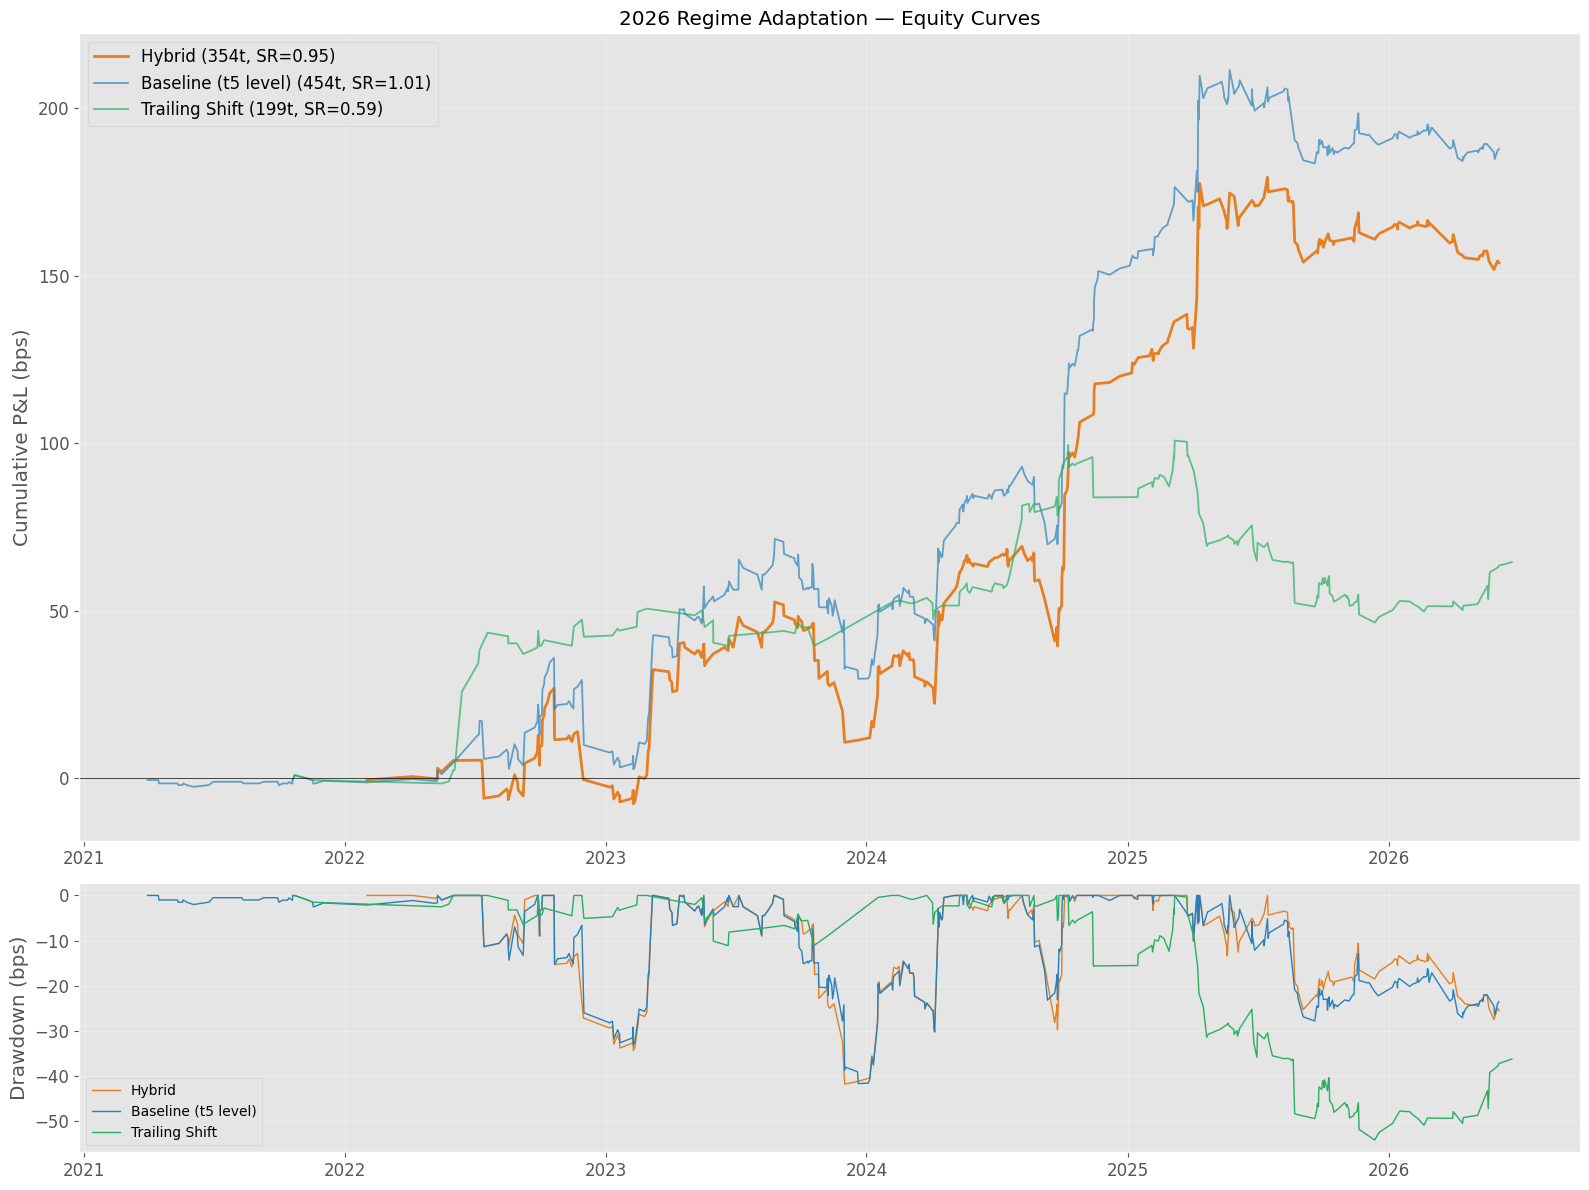

In [6]:
def _sharpe(cl):
    n = len(cl)
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    tpy = n / yrs
    std = cl["pnl_bps"].std()
    avg = cl["pnl_bps"].mean()
    return (avg / std * np.sqrt(tpy)) if std > 0 else 0

COLORS = {"Hybrid": "#e67e22", "Baseline (t5 level)": "#2980b9", "Trailing Shift": "#27ae60"}

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
for name in strategies:
    cl = all_closed[name]
    ax.plot(cl["opened_at"].values, cl["cum_bps"].values,
            lw=2 if name == "Hybrid" else 1.3, color=COLORS[name],
            label=f"{name} ({len(cl)}t, SR={_sharpe(cl):.2f})", alpha=1 if name == "Hybrid" else 0.7)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("2026 Regime Adaptation — Equity Curves")
ax.legend(loc="upper left", fontsize=12)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for name in strategies:
    cl = all_closed[name]
    dd = cl["cum_bps"] - cl["cum_bps"].cummax()
    ax2.plot(cl["opened_at"].values, dd.values, lw=1, color=COLORS[name], label=name)
ax2.set_ylabel("Drawdown (bps)")
ax2.legend(loc="lower left", fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary Comparison

In [7]:
def _sharpe(cl):
    n = len(cl)
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    tpy = n / yrs
    std = cl["pnl_bps"].std()
    avg = cl["pnl_bps"].mean()
    return (avg / std * np.sqrt(tpy)) if std > 0 else 0

def calc_stats(cl, name):
    hawk = cl["direction"] == 1
    return {
        "Strategy": name, "Trades": len(cl),
        "Hawk / Dove": f"{hawk.sum()} / {(~hawk).sum()}",
        "Cum bps": cl["pnl_bps"].sum(),
        "Avg bps": cl["pnl_bps"].mean(),
        "Med bps": cl["pnl_bps"].median(),
        "Std bps": cl["pnl_bps"].std(),
        "Hit Rate": cl["profitable"].mean(),
        "Sharpe": _sharpe(cl),
        "Max DD": (cl["cum_bps"] - cl["cum_bps"].cummax()).min(),
        "Skew": cl["pnl_bps"].skew(),
        "Hawk bps": cl.loc[hawk, "pnl_bps"].sum(),
        "Dove bps": cl.loc[~hawk, "pnl_bps"].sum(),
    }

rows = [calc_stats(all_closed[n], n) for n in strategies]
summary = pd.DataFrame(rows)
display(summary.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Med bps": "{:+.3f}",
    "Std bps": "{:.2f}", "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    "Max DD": "{:.1f}", "Skew": "{:+.2f}",
    "Hawk bps": "{:+.1f}", "Dove bps": "{:+.1f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

,Strategy,Trades,Hawk / Dove,Cum bps,Avg bps,Med bps,Std bps,Hit Rate,Sharpe,Max DD,Skew,Hawk bps,Dove bps
0,Hybrid,354,319 / 35,+153.8,+0.435,+0.368,4.13,58.2%,0.95,-41.9,+1.62,+177.6,-23.8
1,Baseline (t5 level),454,380 / 74,+187.8,+0.414,+0.156,3.82,57.5%,1.01,-41.8,+1.58,+197.3,-9.5
2,Trailing Shift,199,91 / 108,+64.5,+0.324,+0.284,3.59,53.3%,0.59,-54.3,+1.64,+49.1,+15.4


## 7. Hybrid Strategy — P&L Distribution

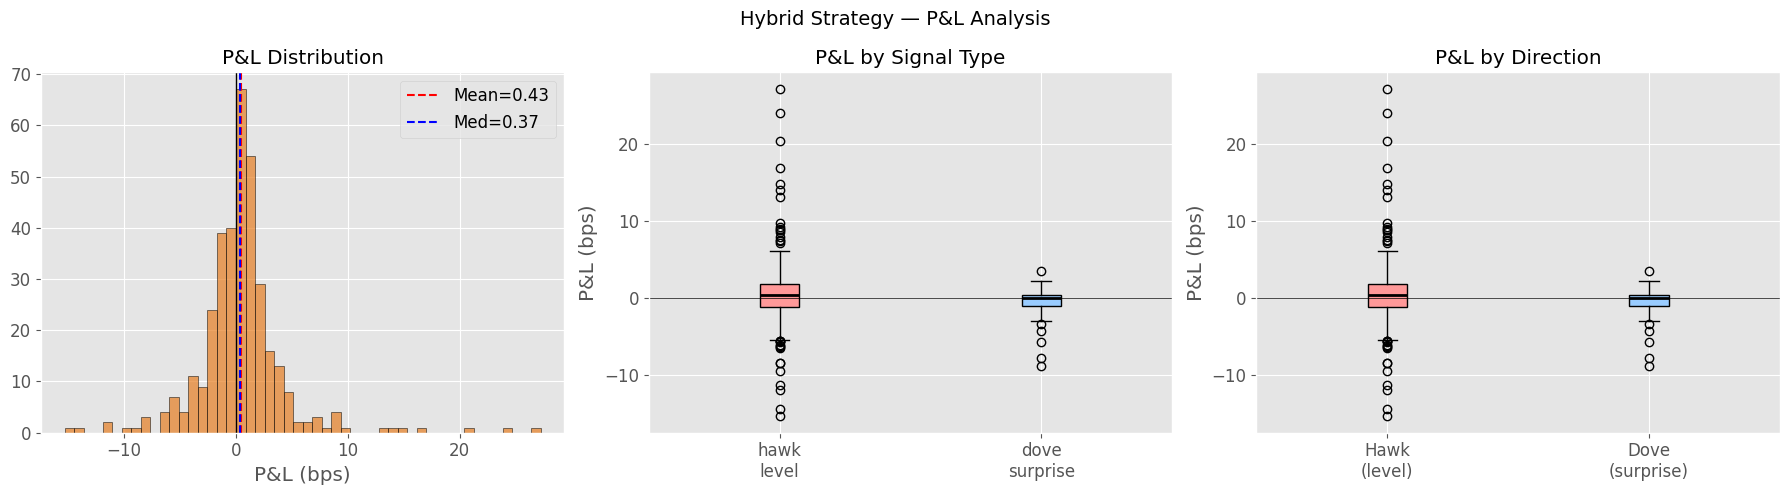

Percentiles:


,Pct,bps
0,1%,-10.27
1,5%,-5.46
2,10%,-3.35
3,25%,-1.06
4,50%,0.37
5,75%,1.58
6,90%,3.78
7,95%,5.81
8,99%,15.84


In [8]:
cl = all_closed["Hybrid"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
ax = axes[0]
ax.hist(cl["pnl_bps"], bins=50, alpha=0.7, color="#e67e22", edgecolor="black")
ax.axvline(0, color="k", lw=1)
avg, med = cl["pnl_bps"].mean(), cl["pnl_bps"].median()
ax.axvline(avg, color="red", ls="--", lw=1.5, label=f"Mean={avg:.2f}")
ax.axvline(med, color="blue", ls="--", lw=1.5, label=f"Med={med:.2f}")
ax.set_xlabel("P&L (bps)"); ax.set_title("P&L Distribution"); ax.legend()

# Box by signal type
ax2 = axes[1]
types = cl["signal_type"].unique()
data = [cl.loc[cl["signal_type"] == t, "pnl_bps"] for t in types]
bp = ax2.boxplot(data, tick_labels=[t.replace("_", "\n") for t in types],
                 patch_artist=True, medianprops={"color": "black", "lw": 2})
colors_box = {"hawk_level": "#ff9999", "dove_surprise": "#99ccff", "level": "#cccccc", "shift": "#99ff99"}
for box, t in zip(bp["boxes"], types):
    box.set_facecolor(colors_box.get(t, "#dddddd"))
ax2.axhline(0, color="k", lw=0.5)
ax2.set_ylabel("P&L (bps)"); ax2.set_title("P&L by Signal Type")

# Box by direction
ax3 = axes[2]
hawk_bps = cl.loc[cl["direction"] == 1, "pnl_bps"]
dove_bps = cl.loc[cl["direction"] == -1, "pnl_bps"]
bp2 = ax3.boxplot([hawk_bps, dove_bps], tick_labels=["Hawk\n(level)", "Dove\n(surprise)"],
                  patch_artist=True, medianprops={"color": "black", "lw": 2})
bp2["boxes"][0].set_facecolor("#ff9999"); bp2["boxes"][1].set_facecolor("#99ccff")
ax3.axhline(0, color="k", lw=0.5)
ax3.set_ylabel("P&L (bps)"); ax3.set_title("P&L by Direction")

plt.suptitle("Hybrid Strategy — P&L Analysis", fontsize=14)
plt.tight_layout(); plt.show()

pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_df = pd.DataFrame({"Pct": [f"{p}%" for p in pcts], "bps": np.percentile(cl["pnl_bps"], pcts)})
print("Percentiles:"); display(pct_df.style.format({"bps": "{:.2f}"}))

## 8. Calendar-Year Breakdown

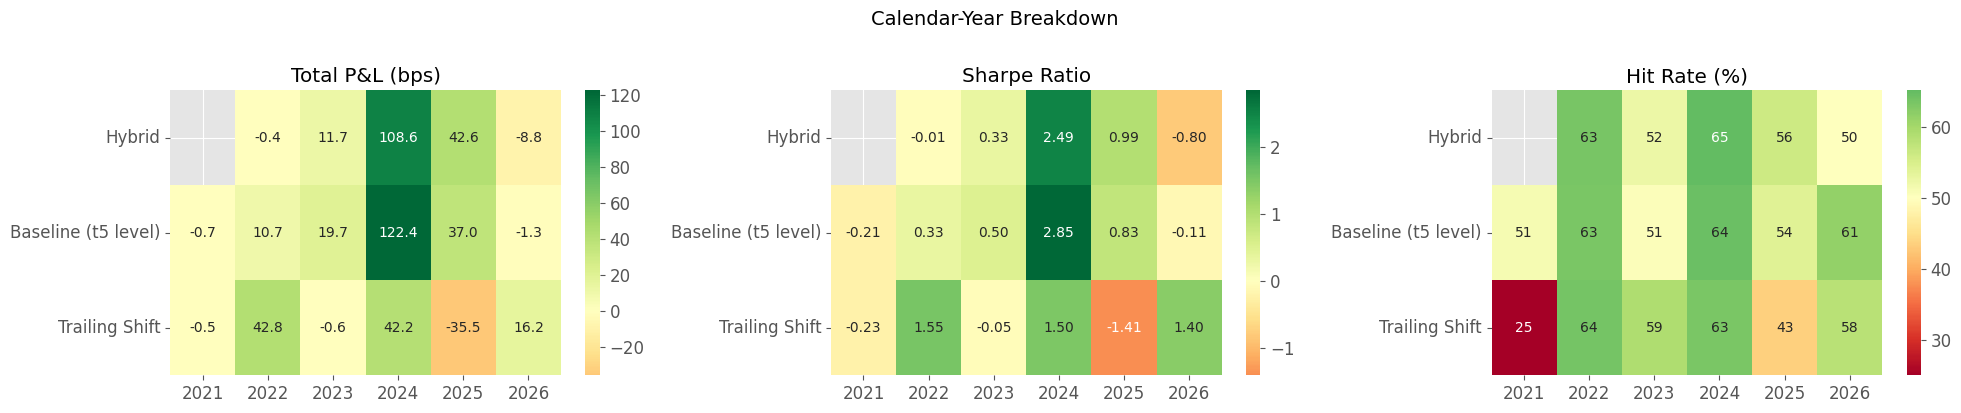

In [9]:
all_years = sorted(set(y for cl in all_closed.values() for y in cl["year"].unique()))
yr_bps = pd.DataFrame(index=list(strategies.keys()), columns=all_years, dtype=float)
yr_sr = yr_bps.copy()
yr_hit = yr_bps.copy()

for name in strategies:
    cl = all_closed[name]
    for yr, grp in cl.groupby("year"):
        n = len(grp); avg = grp["pnl_bps"].mean(); std = grp["pnl_bps"].std()
        yr_bps.loc[name, yr] = grp["pnl_bps"].sum()
        yr_sr.loc[name, yr] = (avg / std * np.sqrt(n)) if std > 0 else 0
        yr_hit.loc[name, yr] = grp["profitable"].mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
sns.heatmap(yr_bps.astype(float), annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=axes[0])
axes[0].set_title("Total P&L (bps)")
sns.heatmap(yr_sr.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Sharpe Ratio")
sns.heatmap(yr_hit.astype(float)*100, annot=True, fmt=".0f", cmap="RdYlGn", center=50, ax=axes[2])
axes[2].set_title("Hit Rate (%)")
for ax in axes: ax.set_ylabel("")
plt.suptitle("Calendar-Year Breakdown", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 9. Hawk vs Dove — Hybrid Strategy

,trades,total_bps,avg_bps,med_bps,std_bps,hit_rate
signal_type,,,,,,
hawk_level,319,+177.6,+0.557,+0.445,4.25,59.2%
dove_surprise,35,-23.8,-0.679,-0.011,2.61,48.6%


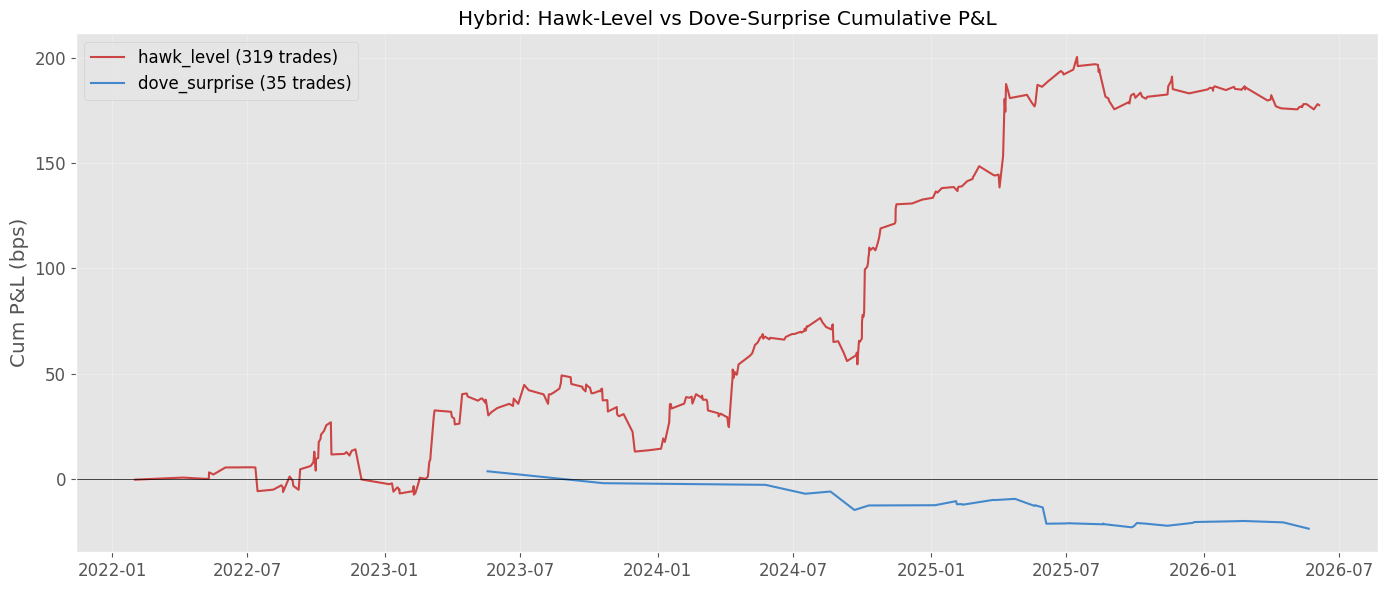

In [10]:
cl = all_closed["Hybrid"]
dir_stats = cl.groupby("signal_type").agg(
    trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
    avg_bps=("pnl_bps", "mean"), med_bps=("pnl_bps", "median"),
    std_bps=("pnl_bps", "std"), hit_rate=("profitable", "mean")
).sort_values("total_bps", ascending=False)
display(dir_stats.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "med_bps": "{:+.3f}",
    "std_bps": "{:.2f}", "hit_rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(14, 6))
for st, color in [("hawk_level", "#cc4444"), ("dove_surprise", "#4488cc")]:
    mask = cl["signal_type"] == st
    sub = cl[mask].sort_values("opened_at")
    if len(sub) == 0: continue
    ax.plot(sub["opened_at"].values, sub["pnl_bps"].cumsum().values,
            lw=1.5, color=color, label=f"{st} ({mask.sum()} trades)")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cum P&L (bps)"); ax.set_title("Hybrid: Hawk-Level vs Dove-Surprise Cumulative P&L")
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Speaker Attribution — Hybrid

,,trades,total_bps,avg_bps,hit_rate,avg_surprise
speaker,signal_type,,,,,
Bowman,hawk_level,22,+34.4,+1.562,54.5%,-3.5
Barkin,hawk_level,49,+30.4,+0.620,59.2%,-5.0
Musalem,hawk_level,20,+27.3,+1.365,70.0%,-6.1
Logan,hawk_level,14,+19.6,+1.398,57.1%,2.4
Collins,hawk_level,5,+16.1,+3.216,80.0%,-11.4
Bostic,hawk_level,27,+14.1,+0.523,66.7%,-3.2
Kashkari,hawk_level,11,+13.6,+1.233,72.7%,-6.0
Waller,hawk_level,21,+13.1,+0.622,76.2%,-2.7
Powell,hawk_level,34,+10.1,+0.296,61.8%,-2.5


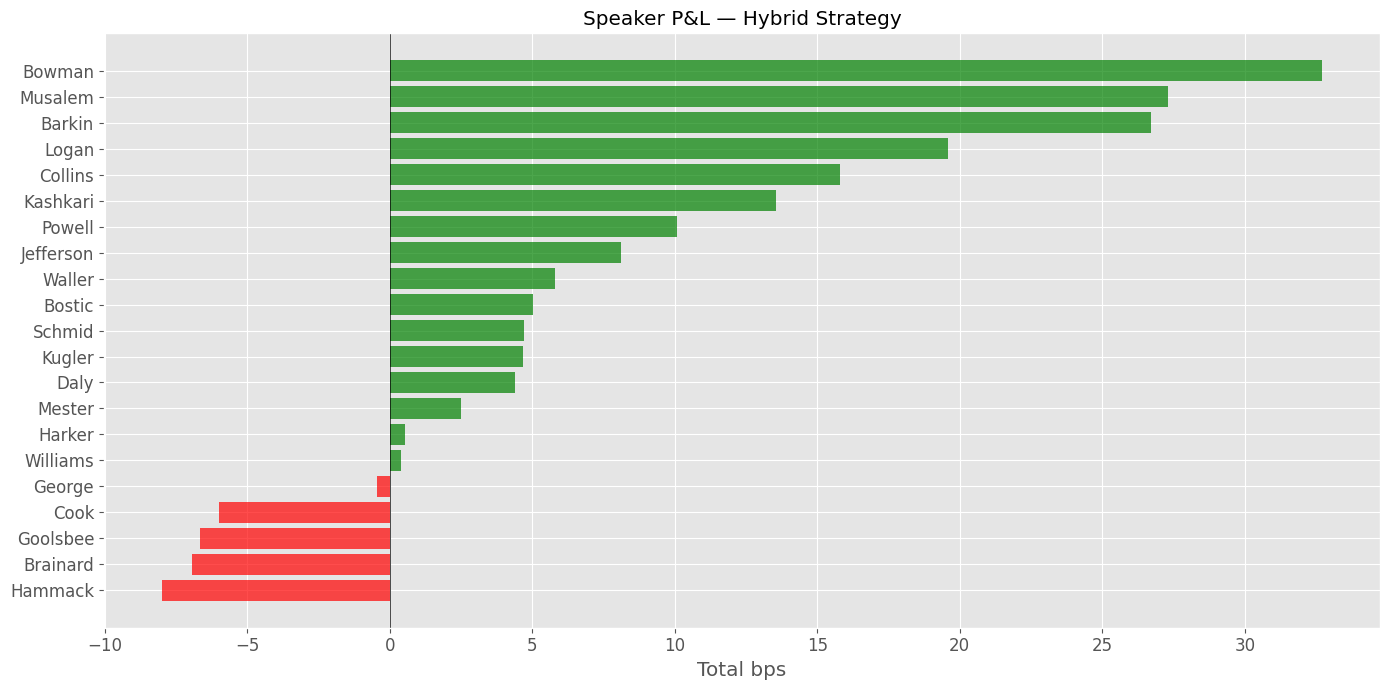

In [11]:
cl = all_closed["Hybrid"]
sp = cl.groupby(["speaker", "signal_type"]).agg(
    trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
    avg_bps=("pnl_bps", "mean"), hit_rate=("profitable", "mean"),
    avg_surprise=("surprise", "mean"),
).sort_values("total_bps", ascending=False)
display(sp.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "hit_rate": "{:.1%}",
    "avg_surprise": "{:.1f}"}))

# Bar chart
sp_total = cl.groupby("speaker")["pnl_bps"].sum().sort_values()
fig, ax = plt.subplots(figsize=(14, 7))
colors = ["green" if x > 0 else "red" for x in sp_total]
ax.barh(sp_total.index, sp_total.values, color=colors, alpha=0.7)
ax.axvline(0, color="k", lw=0.5); ax.set_xlabel("Total bps")
ax.set_title("Speaker P&L — Hybrid Strategy")
plt.tight_layout(); plt.show()

## 11. Rolling 50-Trade Sharpe

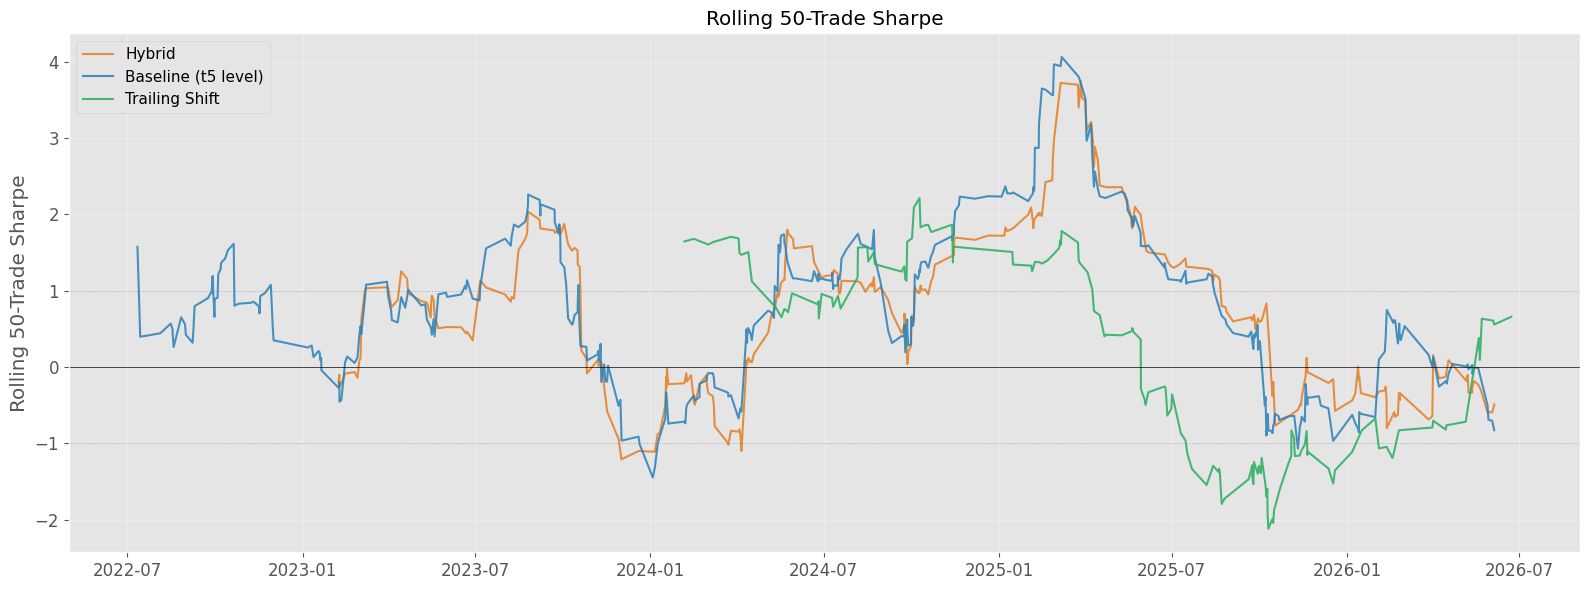

In [12]:
fig, ax = plt.subplots(figsize=(16, 6))
W = 50
for name in strategies:
    cl = all_closed[name].sort_values("opened_at")
    if len(cl) < W: continue
    ravg = cl["pnl_bps"].rolling(W).mean()
    rstd = cl["pnl_bps"].rolling(W).std()
    rsr = (ravg / rstd) * np.sqrt(W)
    ax.plot(cl["opened_at"].values, rsr.values, lw=1.5,
            color=COLORS[name], label=name, alpha=0.85)
ax.axhline(0, color="k", lw=0.5)
ax.axhline(1, color="grey", lw=0.5, ls=":"); ax.axhline(-1, color="grey", lw=0.5, ls=":")
ax.set_ylabel(f"Rolling {W}-Trade Sharpe"); ax.set_title(f"Rolling {W}-Trade Sharpe")
ax.legend(loc="upper left", fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Monthly P&L Heatmap — Hybrid

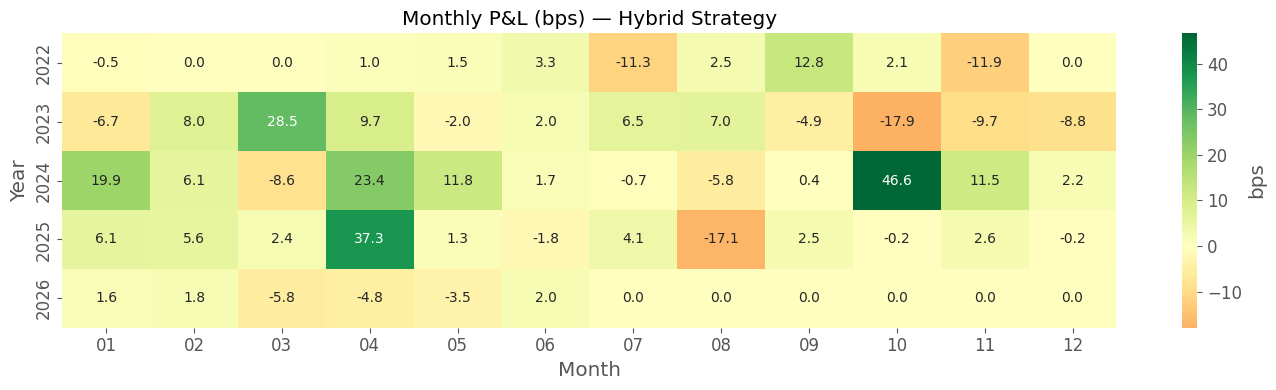

In [13]:
cl = all_closed["Hybrid"]
cl["yr"] = cl["opened_at"].dt.year
cl["mo"] = cl["opened_at"].dt.month

monthly = cl.groupby(["yr", "mo"])["pnl_bps"].sum().unstack(fill_value=0)
monthly.columns = [f"{m:02d}" for m in monthly.columns]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(monthly.astype(float), annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax,
            cbar_kws={"label": "bps"})
ax.set_title("Monthly P&L (bps) — Hybrid Strategy")
ax.set_ylabel("Year"); ax.set_xlabel("Month")
plt.tight_layout(); plt.show()

## 13. Dove Surprise Signal Analysis

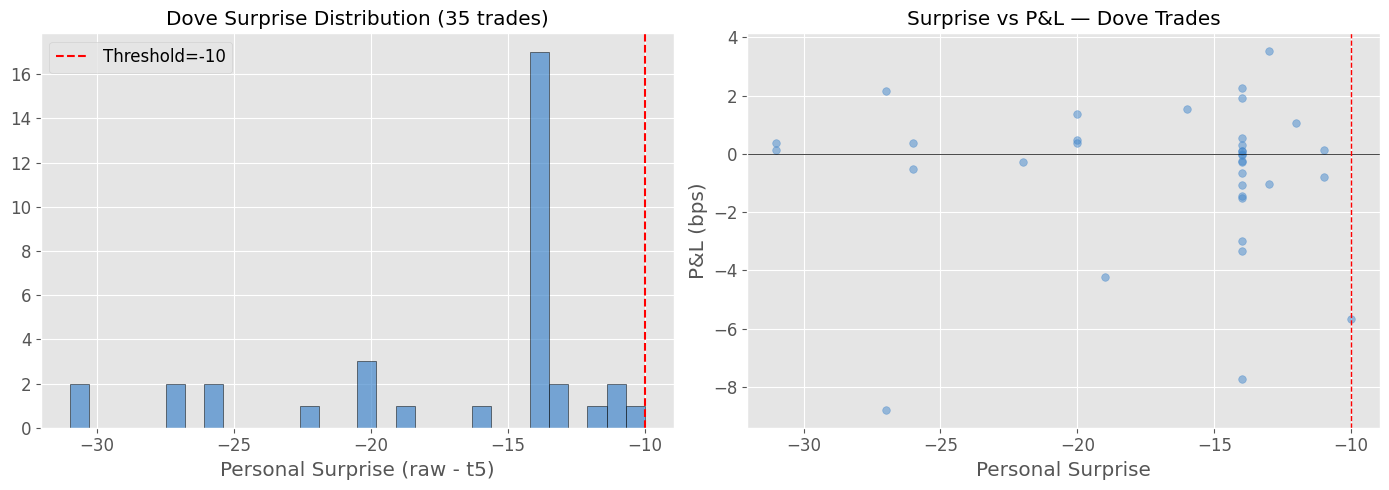

Dove surprise stats: mean=-16.9, median=-14.0, avg_relevance=71.5
Dove P&L: cum=-23.8 bps, avg=-0.68, hit=48.6%

Top dove-surprise speakers:


,n,bps,hit
speaker,,,
Jefferson,3,+7.2,100%
Williams,3,+1.8,67%
Cook,1,+0.1,100%
Collins,1,-0.3,0%
Daly,1,-1.0,0%
Bowman,3,-1.7,33%
Barkin,2,-3.7,0%
Kugler,1,-4.2,0%
Harker,1,-5.7,0%


In [14]:
cl = all_closed["Hybrid"]
dove = cl[cl["signal_type"] == "dove_surprise"].copy()

if len(dove) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.hist(dove["surprise"], bins=30, alpha=0.7, color="#4488cc", edgecolor="black")
    ax.axvline(DOVE_SURPRISE_THRESH, color="red", ls="--", lw=1.5, label=f"Threshold={DOVE_SURPRISE_THRESH}")
    ax.set_xlabel("Personal Surprise (raw - t5)")
    ax.set_title(f"Dove Surprise Distribution ({len(dove)} trades)")
    ax.legend()

    ax2 = axes[1]
    ax2.scatter(dove["surprise"], dove["pnl_bps"], alpha=0.5, color="#4488cc", s=30)
    ax2.axhline(0, color="k", lw=0.5); ax2.axvline(DOVE_SURPRISE_THRESH, color="red", ls="--", lw=1)
    ax2.set_xlabel("Personal Surprise"); ax2.set_ylabel("P&L (bps)")
    ax2.set_title("Surprise vs P&L — Dove Trades")
    plt.tight_layout(); plt.show()

    print(f"Dove surprise stats: mean={dove['surprise'].mean():.1f}, "
          f"median={dove['surprise'].median():.1f}, "
          f"avg_relevance={dove['relevance'].mean():.1f}")
    print(f"Dove P&L: cum={dove['pnl_bps'].sum():+.1f} bps, "
          f"avg={dove['pnl_bps'].mean():+.2f}, hit={dove['profitable'].mean():.1%}")
    print()
    print("Top dove-surprise speakers:")
    ds = dove.groupby("speaker").agg(n=("pnl_bps","count"), bps=("pnl_bps","sum"),
                                      hit=("profitable","mean")).sort_values("bps", ascending=False)
    display(ds.style.format({"bps": "{:+.1f}", "hit": "{:.0%}"}))
else:
    print("No dove-surprise trades.")

## 14. Annual P&L Comparison

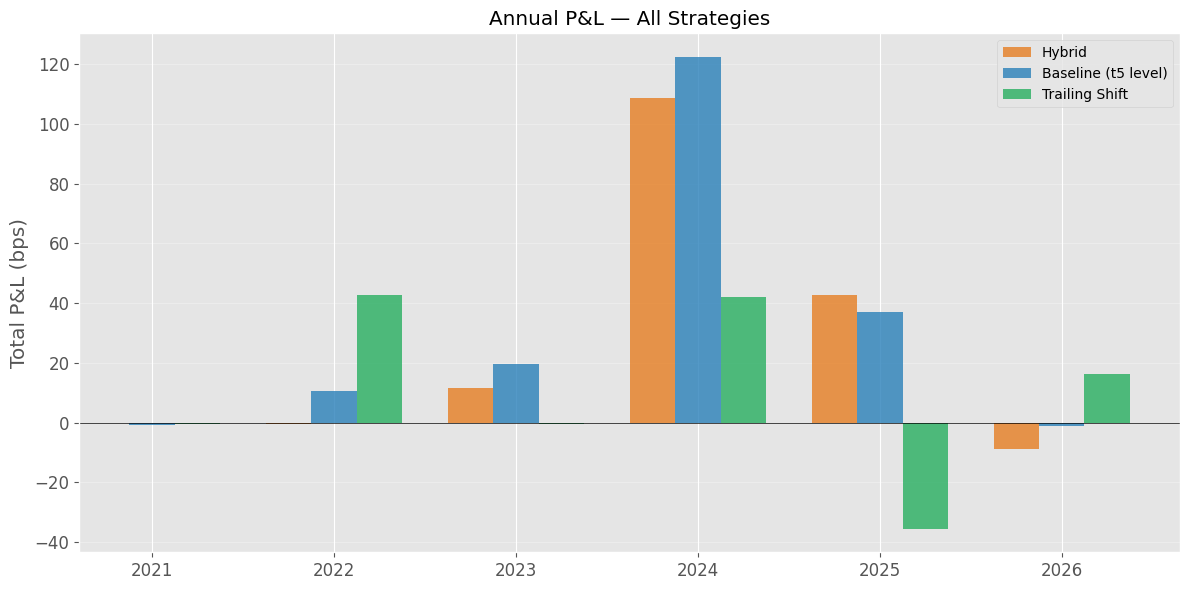

Positive years:
  Hybrid                    3/6
  Baseline (t5 level)       4/6
  Trailing Shift            3/6


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_years))
w = 0.25
for i, name in enumerate(strategies):
    vals = [yr_bps.loc[name, yr] if yr in yr_bps.columns else 0 for yr in all_years]
    ax.bar(x + (i-1)*w, vals, w, label=name, color=COLORS[name], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(all_years)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Total P&L (bps)"); ax.set_title("Annual P&L — All Strategies")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print("Positive years:")
for name in strategies:
    vals = [yr_bps.loc[name, yr] for yr in all_years]
    pos = sum(1 for v in vals if v > 0)
    print(f"  {name:25s} {pos}/{len(vals)}")

## 15. Trade Log — Hybrid

In [16]:
cl = all_closed["Hybrid"]
log = cl[["opened_at","closed_at","speaker","signal_type","direction_label",
          "t5","raw_score","surprise","relevance","pnl_bps","profitable","cum_bps"]].copy()
log = log.sort_values("opened_at").reset_index(drop=True)
display(log.style.format({
    "t5": "{:.0f}", "raw_score": "{:.0f}", "surprise": "{:.0f}",
    "relevance": "{:.0f}", "pnl_bps": "{:+.2f}", "cum_bps": "{:+.1f}",
}).bar(subset=["pnl_bps"], color=["#d65f5f", "#5fba7d"], align="zero"))

,opened_at,closed_at,speaker,signal_type,direction_label,t5,raw_score,surprise,relevance,pnl_bps,profitable,cum_bps
0,2022-01-31 11:55:00-05:00,2022-01-31 15:40:00-05:00,George,hawk_level,hawk,13,21,8,67,-0.46,False,-0.5
1,2022-04-05 13:15:00-04:00,2022-04-05 16:59:00-04:00,Williams,hawk_level,hawk,10,34,24,63,+0.99,True,+0.5
2,2022-05-06 08:30:00-04:00,2022-05-06 12:15:00-04:00,Williams,hawk_level,hawk,10,34,24,63,-0.61,False,-0.1
3,2022-05-10 06:55:00-04:00,2022-05-10 10:40:00-04:00,Williams,hawk_level,hawk,10,34,24,63,+0.13,True,+0.0
4,2022-05-10 12:15:00-04:00,2022-05-10 16:00:00-04:00,Waller,hawk_level,hawk,32,21,-11,58,+2.98,True,+3.0
5,2022-05-16 08:10:00-04:00,2022-05-16 11:55:00-04:00,Williams,hawk_level,hawk,27,47,20,78,-1.02,False,+2.0
6,2022-06-01 10:45:00-04:00,2022-06-01 14:30:00-04:00,Williams,hawk_level,hawk,27,47,20,78,+3.34,True,+5.3
7,2022-07-07 12:15:00-04:00,2022-07-07 16:00:00-04:00,Waller,hawk_level,hawk,33,19,-14,66,+0.09,True,+5.4
8,2022-07-11 13:20:00-04:00,2022-07-11 16:59:00-04:00,Williams,hawk_level,hawk,38,45,7,73,-0.10,False,+5.3
9,2022-07-14 10:15:00-04:00,2022-07-14 14:00:00-04:00,Waller,hawk_level,hawk,33,19,-14,66,-11.26,False,-5.9
